<a href="https://colab.research.google.com/github/arihurtado29/prediccion-progresion-diabetes/blob/main/regresion_lineal_diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analítica e inteligencia de negocios para la toma de decisiones
## Actividad 3. Creación de un modelo de predicción y visualización de datos en Python

Usaremos el lenguaje de programación Python y la biblioteca de aprendizaje automático scikit-learn para construir un modelo de predicción usando el dataset `Diabetes`.


| Variable   | Descripción                                            |
|------------|--------------------------------------------------------|
| Age        | Edad del paciente en años.                             |
| Sex        | Género del paciente (0 = Masculino, 1 = Femenino).    |
| BMI        | Índice de masa corporal (IMC) del paciente.           |
| BP         | Presión sanguínea media del paciente.                 |
| S1         | Nivel de concentración de plasma de glucosa en ayunas.|
| S2         | Nivel de lipoproteína de alta densidad (HDL)          |
| S3         | Nivel de lipoproteína de baja densidad (LDL)          |
| S4         | Nivel de total de colesterol en plasma.               |
| S5         | Logaritmo natural de la concentración de triglicéridos.|
| S6         | Medida de la concentración de plasma de insulina.     |
| Target     | Medida cuantitativa de la progresión de la enfermedad diabetes después de un año.|

El objetivo principal de este conjunto de datos es predecir la progresión de la diabetes (la variable "Target") en función de las otras variables, que son características demográficas y biomédicas de los pacientes. Se utiliza comúnmente en problemas de regresión en los que se busca predecir un valor numérico.

Este conjunto de datos se utiliza ampliamente en la investigación y la enseñanza de la ciencia de datos y el aprendizaje automático debido a su disponibilidad y su relevancia en el campo de la salud.

## Pasos:

1. Carga el dataset.
1. Prepara los datos: realiza la limpieza y transformación.
1. Realiza la división del conjunto de datos en conjuntos de entrenamiento y prueba.
1. Realiza el entrenamiento usando el modelo de predicción regresión lineal.
1. Evalúa el rendimiento del modelo utilizando las métricas relevantes : Error Cuadrático Medio ($MSE$) y el Coeficiente de determinación ($R^2$).



### Cargar el dataset

In [ ]:
from sklearn.datasets import load_diabetes
import pandas as pd
data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)
df
# 442 filas x 10 columnas

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df['target'] = data.target
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


Vamos a entender los datos `Target` es la progresión de la enfermedad un año. Un valor más alto en la variable `Target` indica una progresión más rápida de la enfermedad

Es posible que te preguntes qué significado tienen los valores, ya que en `Age` vemos datos como *0.038076* que no parece ser una edad correcta, lo que ocurre es que los valores de los atributos han sido previamente centrados y escalados por su desviación estándar.

Así, que cuando ves valores como el mencionado *0.038076* para el atributo `Age`, no estás viendo la edad en años. En cambio, estás viendo cuántas desviaciones estándar está ese valor particular de la media original de la edad en el conjunto de datos.

### Limpieza del dataset

Eliminar filas que tengan columnas de edad vacías

In [ ]:
# Mostramos el tamaño del dataframe
print(len(df))
# Eliminamos filas con valores vacíos en AGE
df.dropna(subset=['age'], inplace=True)
# Mostramos el nuevo tamaño del dataframe
print(len(df))

442
442


Como podemos observar, la limpieza del dataset nos arrojó 442 datos.

### Seleccionamos las variables de interés

Vamos a realizar la predicción con base en la variable independiente **`AGE`**.

In [ ]:

X = df[['age']]
y = df['target']

# División del dataset

In [ ]:
from sklearn.model_selection import train_test_split

# Seleccionar variables de interés
X = df[['age']]
y = df['target']

# Dividir el dataset en conjunto de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Mostrar los datos de la divisón del dataset
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((353, 1), (89, 1), (353,), (89,))

Se dividió el dataset en dos partes:

    Conjunto de entrenamiento: 353 registros.
    Conjunto de prueba: 89 registros.

El conjunto de entrenamiento se utilizará para entrenar el modelo de regresión lineal, mientras que el conjunto de prueba se utilizará para evaluar su rendimiento.

### Entrenar el modelo

In [ ]:
from sklearn.linear_model import LinearRegression

# Crear y entrenar el modelo de regresión lineal
model = LinearRegression()
model.fit(X_train, y_train)

# Realizar predicciones
y_train_pred = model.predict(X_train) # entrenamiento
y_test_pred = model.predict(X_test) # prueba

## Visualizar los resultados

*   Los puntos azules representan los datos de entrenamiento.
*   Los puntos rojos representan los datos de prueba.
*   La línea negra es la línea de regresión que nuestro modelo ha aprendido.

La línea de regresión intenta ajustarse lo mejor posible a los datos. A partir de esta línea, podemos hacer predicciones sobre la progresión de la diabetes de acuerdo a la edad del paciente. Por ejemplo, un paciente con un mayor edad podría tener tendencia a tener una progresión más más rápida.

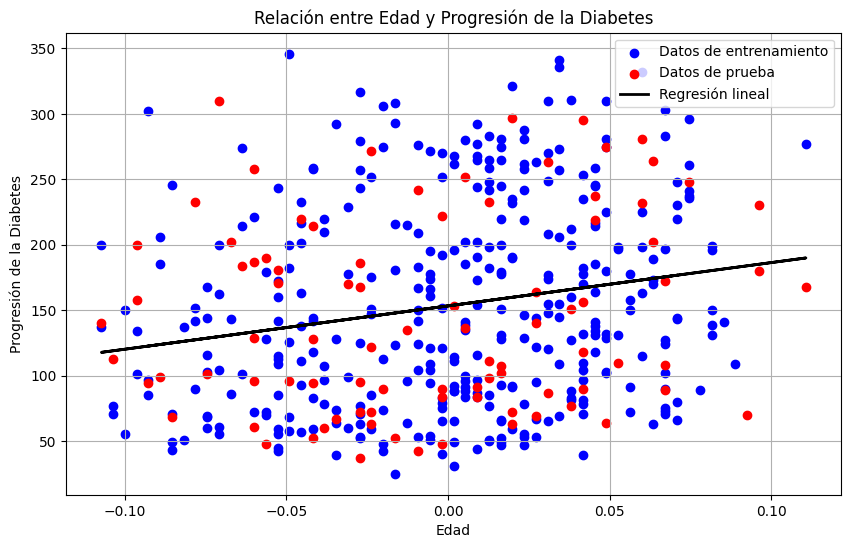

In [ ]:
import matplotlib.pyplot as plt

# Visualizar los resultados
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', label="Datos de entrenamiento")
plt.scatter(X_test, y_test, color='red', label="Datos de prueba")
plt.plot(X_train, y_train_pred, color='black', linewidth=2, label="Regresión lineal")
plt.title("Relación entre Edad y Progresión de la Diabetes")
plt.xlabel("Edad")
plt.ylabel("Progresión de la Diabetes")
plt.legend()
plt.grid(True)
plt.show()

Analizando la visualización de la gráfica, podemos mencionar las siguientes conclusiones del modelo:

**Con base en el modelo de regresión lineal y la visualización de los resultados obtenidos, se puede predeccir que la relación entre la edad y la progresión de la Diabetes es muy débil o casu nula, ya que la línea de regresión tiene una pendiente muy pequeña. Esto nos induca que la edad no influye significativamente en la progresión de la diabetes.**

## Evaluar el modelo

1. Error Cuadrático Medio ($MSE$)
2. Coeficiente de determinación ($R^2$)

### Error Cuadrático Medio ($MSE$):

Es una métrica que nos indica cuán alejadas están nuestras predicciones de los valores reales. Se calcula como el promedio de los errores cuadrados:

$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$

Donde:
- $y_i$ es el valor real.
- $\hat{y}_i$ es la predicción.
- $n$ es el número total de ejemplos.

Un MSE más bajo indica que el modelo se ajusta mejor a los datos. Sin embargo, debemos tener cuidado de no sobreajustar el modelo a los datos de entrenamiento, ya que esto puede llevar a un rendimiento deficiente en datos no vistos previamente.

In [ ]:
from sklearn.metrics import mean_squared_error

# Calcular los errores cuadráticos medios (MSE)
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

# Mostrar los MSE
mse_train, mse_test


(5841.75149910816, 5254.231976236004)

### $MSE$ resultado del entrenamiento

A continuación, se muestran los errores cuadráticos medios ($MSE$) para ambos conjuntos:

*   Error cuadrático medio en el conjunto de entrenamiento: **5841.75**
*   Error cuadrático medio en el conjunto de prueba: **5254.23**

El error cuadrático medio ($MSE$) mide la cantidad de error que hay entre dos conjuntos de datos, en este caso, entre los valores reales y las predicciones. En general, ***un MSE más bajo*** indica que el modelo tiene un mejor rendimiento.

### Coeficiente de determinación ($R^2$)

Es una medida de cuánta variación en la variable dependiente es explicada por el modelo. Su valor varía entre 0 y 1, siendo 1 una predicción perfecta y 0 indicando que el modelo no es mejor que simplemente tomar el promedio de la variable de respuesta. Es una métrica útil para determinar qué tan bien se ajusta el modelo a los datos observados.

$$R^2 = 1 - \frac{\text{MSE del modelo}}{\text{MSE del modelo nulo}}$$

Donde el modelo nulo es un modelo que siempre predice el promedio de la variable de respuesta, sin tener en cuenta las características.

In [ ]:
from sklearn.metrics import r2_score

# Calcular los coeficientes de determinación (R^2)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

# Mostrar los coeficientes de determinación (R^2)
r2_train, r2_test


(0.0386160540134205, 0.008289640305771506)

El coeficiente de determinación $R^2$ para nuestro modelo es:

- $R^2$ en el conjunto de entrenamiento: **0.0386**
- $R^2$ en el conjunto de prueba: **0.0082**

Esto significa que:

- Nuestro modelo explica aproximadamente el **3.86 %** de la variabilidad en la progresión de la enfermedad en el conjunto de entrenamiento.
- Nuestro modelo explica aproximadamente el **0.82 %** de la variabilidad en la progresión de la enfermedad en el conjunto de prueba.

Un $R^2$ de 1 indicaría que el modelo explica toda la variabilidad en la progresión de la enfermedad, mientras que un $R^2$ de 0 indicaría que el modelo no explica ninguna variabilidad.

Por lo tanto, los valores obtenidos sugieren que el modelo tiene un ajuste no muy adecuado a los datos, por lo que hay espacio para mejorar, una forma de hacerlo es analizando lass características.

## Identificación de características

La identificación de características (**feature selection**) es el proceso de seleccionar un subconjunto de características relevantes para la construcción de modelos, *eliminando aquellas que no aportan mucha información* o que pueden ser redundantes. Esto puede mejorar el desempeño del modelo, reducir la complejidad y aumentar la velocidad de entrenamiento.

In [ ]:
from sklearn.feature_selection import RFE

# Utilizar RFE con un modelo de regresión lineal
estimator = LinearRegression()

# Seleccionar las 5 características más importantes
selector = RFE(estimator, n_features_to_select=5, step=1)
selector = selector.fit(df.drop("target", axis=1), df["target"])


# Obtener y mostrar las características seleccionadas
selected_features = df.columns[:-1] [selector.support_]
selected_features

Index(['bmi', 'bp', 's1', 's2', 's5'], dtype='object')

### Resultados RFE

Tras aplicar el método de Eliminación Recursiva de Características (RFE) con un modelo de regresión lineal, las 5 características más relevantes identificadas en el dataset **Diabetes** son:

1. **BMI**: Índice de masa corporal (IMC) del paciente.
2. **BP**: Presión sanguínea media del paciente.
3. **S1**: Nivel de concentración de plasma de glucosa en ayunas.
4. **S2**: Nivel de lipoproteína de alta densidad (HDL)
5. **S3**: Nivel de lipoproteína de baja densidad (LDL)

Estas características se consideran las más influyentes en la predicción de la progresión de la enfermedad según el método RFE con un modelo de regresión lineal.

### Re-entrenar con las características seleccionadas

In [ ]:
from sklearn.metrics import r2_score

# Seleccionar las características identificadas por RFE
X_selected = df[selected_features]

# Dividir el dataset con las características seleccionadas en conjunto de entrenamiento y prueba
X_train_selected, X_test_selected = train_test_split(X_selected, test_size=0.2, random_state=42)

# Crear y entrenar el modelo de regresión lineal con las características seleccionadas
model_selected = LinearRegression()
model_selected.fit(X_train_selected, y_train)

# Realizar predicciones en el conjunto de entrenamiento y de prueba
y_train_pred_selected = model_selected.predict(X_train_selected)
y_test_pred_selected = model_selected.predict(X_test_selected)

# Calcular el error cuadrático medio (MSE) para el entrenamiento y prueba
mse_train_selected = mean_squared_error(y_train, y_train_pred_selected)
mse_test_selected = mean_squared_error(y_test, y_test_pred_selected)

# Calcular el coeficiente de determinación (R^2) para el entrenamiento y prueba
r2_train_selected = r2_score(y_train, y_train_pred_selected)
r2_test_selected = r2_score(y_test, y_test_pred_selected)

# Mostrar el error cuadrático medio (MSE) y el coeficiente de determinación (R^2) para el entrenamiento y prueba
mse_train_selected, mse_test_selected, r2_train_selected, r2_test_selected


(2984.629064421601,
 2976.4942699250846,
 0.5088160686571606,
 0.43820139338997677)

### Resultados del *Feature selection*

**Error Cuadrático Medio ($MSE$):**
- Conjunto de entrenamiento: ***2984.62***
- Conjunto de prueba: ***2976.49***

**Coeficiente de Determinación ($R^2$):**
- Conjunto de entrenamiento: ***0.5088***
- Conjunto de prueba: ***0.4382***

### Interpretación

Comparando con los resultados del modelo original:

- El MSE ha disminuido para ambos conjuntos, lo que indica un mejor ajuste.
- El coeficiente $R^2$ ha aumentado para ambos conjuntos, lo que inidica que el modelo con las características seleccionadas explica un mayor proporción de la variabilidad en la regresión de la enfermedad.

Para concluir, la identificación y selección de características h**a mejorado el desempeño** de nuestro modelo. Estos resultados demuestran **la importancia de seleccionar características relevantes** para mejorar la precisión y la eficiencia del modelo.